In [3]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from numpy import cos, sin

import matplotlib.animation as animation

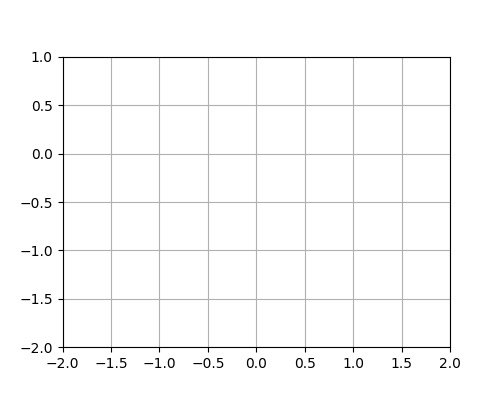

In [30]:
G = 9.8  # acceleration due to gravity, in m/s^2
L1 = 1.0  # length of pendulum 1 in m
L2 = 1.0  # length of pendulum 2 in m
L = L1 + L2  # maximal length of the combined pendulum
M1 = 1.0  # mass of pendulum 1 in kg
M2 = 1.0  # mass of pendulum 2 in kg
t_stop = 2.5  # how many seconds to simulate
history_len = 500  # how many trajectory points to display


def derivs(t, state):
    dydx = np.zeros_like(state)

    dydx[0] = state[1]

    delta = state[2] - state[0]
    den1 = (M1+M2) * L1 - M2 * L1 * cos(delta) * cos(delta)
    dydx[1] = ((M2 * L1 * state[1] * state[1] * sin(delta) * cos(delta)
                + M2 * G * sin(state[2]) * cos(delta)
                + M2 * L2 * state[3] * state[3] * sin(delta)
                - (M1+M2) * G * sin(state[0]))
               / den1)

    dydx[2] = state[3]

    den2 = (L2/L1) * den1
    dydx[3] = ((- M2 * L2 * state[3] * state[3] * sin(delta) * cos(delta)
                + (M1+M2) * G * sin(state[0]) * cos(delta)
                - (M1+M2) * L1 * state[1] * state[1] * sin(delta)
                - (M1+M2) * G * sin(state[2]))
               / den2)

    return dydx

# create a time array from 0..t_stop sampled at 0.02 second steps
dt = 0.001
t = np.arange(0, 20.0, 0.001)


y = np.random.rand(len(t), 2)

x1 = L1*sin(y[:, 0])
y1 = -L1*cos(y[:, 0])

x2 = L2*sin(y[:, 1]) + x1
y2 = -L2*cos(y[:, 1]) + y1

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(autoscale_on=False, xlim=(-L, L), ylim=(-L, 1.))
ax.set_aspect('equal')
ax.grid()

line, = ax.plot([], [], 'o-', lw=2)
trace, = ax.plot([], [], '.-', lw=1, ms=2)
time_template = 'time = %.1fs'
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)


def animate(i):
    thisx = [0, x1[i], x2[i]]
    thisy = [0, y1[i], y2[i]]

    history_x = x2[:i]
    history_y = y2[:i]

    line.set_data(thisx, thisy)
    trace.set_data(history_x, history_y)
    time_text.set_text(time_template % (i*dt))
    return line, trace, time_text


ani = animation.FuncAnimation(
    fig, animate, len(y), interval=1, blit=True)

plt.show()

print(ani)

In [13]:
def animate_dp(x1_vals, x2_vals, t_stop_val, dt) :

    y = np.column_stack((x1_vals, x2_vals))
    print(y.shape)
    
    G = 9.81
    L1 = 1
    L2 = 1
    L = L1 + L2
    M1 = 1
    M2 = 1
    t_stop = t_stop_val
    history_len = 500

    x1 = L1*np.sin(y[:, 0])
    y1 = -L1*np.cos(y[:, 0])
    
    x2 = L2*np.sin(y[:, 1]) + x1
    y2 = -L2*np.cos(y[:, 1]) + y1
    
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(autoscale_on=False, xlim=(-L, L), ylim=(-L, 1.))
    ax.set_aspect('equal')
    ax.grid()
    
    line, = ax.plot([], [], 'o-', lw=2)
    trace, = ax.plot([], [], '.-', lw=1, ms=2)
    time_template = 'time = %.1fs'
    time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)
    
    
    def animate(i):
        thisx = [0, x1[i], x2[i]]
        thisy = [0, y1[i], y2[i]]
    
        history_x = x2[:i]
        history_y = y2[:i]
    
        line.set_data(thisx, thisy)
        trace.set_data(history_x, history_y)
        time_text.set_text(time_template % (i*dt))
        print(dt)
        return line, trace, time_text
    
    
    ani = animation.FuncAnimation(
        fig, animate, len(y), interval=dt*1000, blit=True)
    
    plt.show()

In [14]:
x1test = np.full((500,), np.pi)
x2test = np.full((500,), -np.pi)

(500, 2)


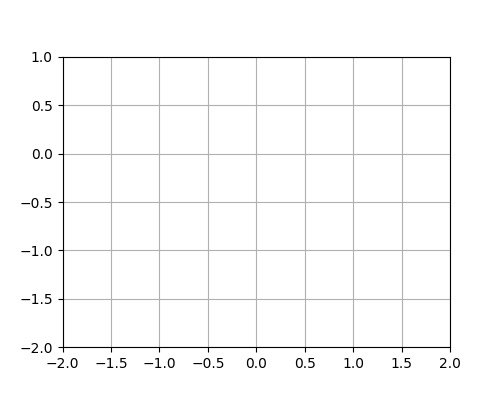

In [15]:
animate_dp(x1test, x2test, 0.5, 0.001)